***Tests***

In [1]:
import torch
import numpy as np
from scipy.optimize import minimize
from modèle import *
from visualisation import *
from pytorch_optim import *
%load_ext autoreload
%autoreload 2

In [2]:
N=3
nb_colonnes_default = 50
T = 300
L = 5
params = {
    "N": N,  # nombre de couches
    "L": L,  # longueur du bassin
    "H": 1,  # hauteur du bassin
    "nb_colonnes_default": 50,  # discrétisation horizontale
    "D": 1e-5,  # coefficient de diffusion
    "T": T,  # temps final pour 20 tours
    "CFL": 0.95,  # facteur CFL
    "u" : [0.01]*N,
    "I_s": 1500,
    "epsilon": 4.6,
    "k_d": 2.99e-4,   # 2.99*10e-5 = 2.99e-4
    "k_r": 4.8e-4,    # 4.8*10e-5 = 4.8e-4
    "k_h": 3.64e-4,   # 3.64*10e-5 = 3.64e-4
    "tau": 6.849,
    "sigma_H": 2.9e-3,  # 2.9*10e-4 = 2.9e-3
    "theta": 3.64e-4 * 2.9e-3,  # k_h * sigma_H
    "I_star": np.sqrt(4.8e-4 / (2.99e-4 * 6.849 * (2.9e-3)**2)),
    "mu_max": 3.64e-4 * 2.9e-3 / (6.849 * 2.9e-3 + 2*np.sqrt((2.99e-4 * 6.849 * (2.9e-3)**2)/4.8e-4))
}

In [3]:
# Un tenseur simple
x = torch.tensor([1, 2, 3])

# Aléatoire
y = torch.randn(2, 3)

# Zéros
z = torch.zeros(3, 3)

print(x, y, z)

tensor([1, 2, 3]) tensor([[-2.0857,  1.2991,  2.0050],
        [-1.2505, -0.3454,  0.2293]]) tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])


In [5]:
a = torch.tensor([1., 2., 3.])
b = torch.tensor([4., 5., 6.])

print(a + b)
print(a * b)
print(a.mean())


tensor([5., 7., 9.])
tensor([ 4., 10., 18.])
tensor(2.)


In [6]:
x = torch.tensor(2.0, requires_grad=True)
y = x**2 + 3*x + 1   # fonction à dériver
y.backward()

print(x.grad)

tensor(7.)


In [7]:
x = torch.tensor(2.0, requires_grad=True)
def f(x):
    return x**2 - x

f(x).backward()

print(x.grad)

tensor(3.)


***Optimiser une fonction simple à deux paramètres.***

In [8]:
x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(1.0, requires_grad=True)

f = (x - 5)**2 + (y - 2)**2 

optim = torch.optim.Adam([x, y], lr=0.001)

for k in range(20000):
    optim.zero_grad()
    f = (x - 5)**2 + (y - 2)**2 
    f.backward()
    optim.step()

print("x:", x.item(), "y:", y.item())

x: 5.0 y: 2.0


Maintenant, essayons d'optimiser cette fonction sur la courbe $y = x^2 - 1$.

In [4]:
x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(1.0, requires_grad=True)

optim = torch.optim.Adam([x, y], lr=0.01)
for p in range(10):
    epsilon = 10**(-p)
    for k in range(1000):
        optim.zero_grad()
        f = (x - 5)**2 + (y - 2)**2 + 1/epsilon*(x**2 - y - 1)**2 #pénalisation
        f.backward()
        optim.step()
    print(f'epsilon = {epsilon}' + ", x:", x.item(), "y:", y.item())

epsilon = 1, x: 2.094550371170044 y: 2.693570613861084
epsilon = 0.1, x: 1.9624724388122559 y: 2.7739076614379883
epsilon = 0.01, x: 1.9472311735153198 y: 2.7838704586029053
epsilon = 0.001, x: 1.9455440044403076 y: 2.7843570709228516
epsilon = 0.0001, x: 1.9440456628799438 y: 2.7792351245880127
epsilon = 1e-05, x: 1.9427201747894287 y: 2.774153470993042
epsilon = 1e-06, x: 1.9407801628112793 y: 2.7666268348693848
epsilon = 1e-07, x: 1.9390605688095093 y: 2.759956121444702
epsilon = 1e-08, x: 1.9372775554656982 y: 2.753044366836548
epsilon = 1e-09, x: 1.9372775554656982 y: 2.753044366836548


On remarque que quand la pénalité devient trop grande, le résultat s'éloigne de la solution (1.94, 2.78). Cela provient du fait que le rapport du gradient calculé et de la learning rate ***lr***  est trop important et empêche de converger vers le minimum. Nous devons adapter le choix de la learning rate à la valeur de $\epsilon$.

Et avec un autre package :

In [5]:
def f(x):
    return (x[0] - 5)**2 + (x[1] - 2)**2 

cons = {'type' : 'eq',
        'fun' : lambda vars: vars[0]**2 - vars[1] - 1}

res = minimize(f, x0=[1.0, 1.0], constraints=cons)
print(res)


     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 9.94614854153955
           x: [ 1.946e+00  2.785e+00]
         nit: 6
         jac: [-6.109e+00  1.570e+00]
        nfev: 19
        njev: 6
 multipliers: [-1.570e+00]


Pour mon problème de recherche des matrices de mélange, plusieurs possibilités : 
- résoudre équation de KKT en calculant les gradients par torch
- utiliser un solver (SLSQP, pulp ou autres) 
dans ce cas, choisir entre un problème sous contrainte, ou un problème relaxé avec pénalisation. 
- coder une descente de gradient à la main

a priori c'est la deuxième solution qui sera la meilleure, mais il reste à pouvoir utiliser pulp sur mes algorithmes, or ils ont pour arguments des entiers (nb_colonnes par exemple) donc non différentiables. De nombreuses reformulations du code à faire.

Essayons, pour se rapprocher du cadre du problème, de minimiser sur l'ensemble des matrices stochastiques par colonnes une fonction simple de ces matrices.

In [6]:

#fonction qui convertit une matrice N*N en vecteur 1D

def matrix_to_vector(P):
    vect = []
    P_ = list(P)
    for line in P:
        for item in line:
            vect.append(item)
    return vect

# et inversement

def vector_to_matrix(v):
    P = np.zeros((N, N))
    for k in range(len(v)):
        P[k//N, k%N] = v[k]
    return P

#ou alors :
def matrix_to_vector(P):
    return P.flatten()

def vector_to_matrix(v, N=3):
    return np.array(v).reshape(N, N)


P = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(P)
v = matrix_to_vector(P)
print(v)
P_ = vector_to_matrix(v)
print(P_)

[[1 2 3]
 [4 5 6]
 [7 8 9]]
[1 2 3 4 5 6 7 8 9]
[[1 2 3]
 [4 5 6]
 [7 8 9]]


In [7]:
#foncion objectif : (prend en argument une liste 1D)

def id(x):
    return sum(x)

constraints = [
    {"type": "ineq", "fun": lambda x, i=i: x[i]} 
    for i in range(9)
]

res = minimize(id, x0=[1.0 for k in range(9)], constraints=constraints)
print(res)
print(vector_to_matrix(res.x))


     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.0
           x: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
                0.000e+00  0.000e+00  0.000e+00  0.000e+00]
         nit: 2
         jac: [ 1.000e+00  1.000e+00  1.000e+00  1.000e+00  1.000e+00
                1.000e+00  1.000e+00  1.000e+00  1.000e+00]
        nfev: 20
        njev: 2
 multipliers: [ 1.000e+00  1.000e+00  1.000e+00  1.000e+00  1.000e+00
                1.000e+00  1.000e+00  1.000e+00  1.000e+00]
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


In [13]:
P = np.array([[1., 0., 0.],
 [0., 2., 0.],
 [0., 0., 3.]])
y = np.array([0, 0, 1])
A = np.array([[0, 0, 1], 
            [0, 1, 0],
            [1, 0, 0]])
print(A@P@y)
print(sum(A@P@y))

[3. 0. 0.]
3.0


In [14]:
def f(x):
    P = vector_to_matrix(x)
    y = np.array([0, 0, 1])
    A = np.array([[0, 0, 1], 
                  [0, 1, 0],
                  [1, 0, 0]])
    v = A@P@y

    return sum(v)

constraints = [
    {"type": "ineq", "fun": lambda x, i=i: x[i]} 
    for i in range(9)
]

res = minimize(f, x0=[1.0 for k in range(9)], constraints=constraints)
print(res)
print(vector_to_matrix(res.x))

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.0
           x: [ 1.000e+00  1.000e+00  0.000e+00  1.000e+00  1.000e+00
                0.000e+00  1.000e+00  1.000e+00  0.000e+00]
         nit: 2
         jac: [ 0.000e+00  0.000e+00  1.000e+00  0.000e+00  0.000e+00
                1.000e+00  0.000e+00  0.000e+00  1.000e+00]
        nfev: 20
        njev: 2
 multipliers: [ 0.000e+00  0.000e+00  1.000e+00  0.000e+00  0.000e+00
                1.000e+00  0.000e+00  0.000e+00  1.000e+00]
[[1. 1. 0.]
 [1. 1. 0.]
 [1. 1. 0.]]


Et maintenant en optimisant sur les matrice stochastiques par colonnes :

In [15]:
def f(x):
    P = vector_to_matrix(x)
    y = np.array([0, 0, 1])
    A = np.array([[0, 0, 1], 
                  [0, 1, 0],
                  [1, 0, 0]])
    v = A@P@y

    return sum(v)

constraints = [
    {"type": "eq", "fun": lambda x, i=i: x[i*N] + x[i*N + 1] + x[i*N + 2] - 1} 
    for i in range(3)
] + [ {"type": "ineq", "fun": lambda x, i=i: x[i]}
    for i in range(N*N)]

res = minimize(f, x0=[1.0 for k in range(9)], constraints=constraints)
print(res)
print(vector_to_matrix(res.x))

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: -3.3306690738754696e-16
           x: [ 5.000e-01  5.000e-01  1.110e-16  5.000e-01  5.000e-01
               -2.220e-16  5.000e-01  5.000e-01 -2.220e-16]
         nit: 2
         jac: [ 0.000e+00  0.000e+00  1.000e+00  0.000e+00  0.000e+00
                1.000e+00  0.000e+00  0.000e+00  1.000e+00]
        nfev: 20
        njev: 2
 multipliers: [-0.000e+00 -2.564e-16 -1.480e-16  0.000e+00  0.000e+00
                1.000e+00  0.000e+00  0.000e+00  1.000e+00  0.000e+00
                0.000e+00  1.000e+00]
[[ 5.00000000e-01  5.00000000e-01  1.11022302e-16]
 [ 5.00000000e-01  5.00000000e-01 -2.22044605e-16]
 [ 5.00000000e-01  5.00000000e-01 -2.22044605e-16]]


Essayons à présent d'implémenter une fonction objectif se rapprochant de notre problème initial.

In [47]:
X = X_init(N, 50, L)

def f(x):
    P = vector_to_matrix(x)
    masse = fonction_objectif(X, 3600, P, params)
    return -masse #car on va minimiser, donc pour maximiser, il nous faut minimiser - (masse totale)

f([1, 0, 0, 0, 0, 1, 0, 1, 0])

NameError: name 'vector_to_matrix' is not defined

In [17]:

ineq_constraints = [
    {"type": "ineq", "fun": lambda x, i=i: x[i]}
    for i in range(N*N)] + [{"type" : "ineq", "fun" : lambda x, i=i: 1 - x[i]}
    for i in range(N*N)
]

eq_constraints = [
    {"type": "eq",
     "fun": lambda x, j=j: sum(x[i*N + j] for i in range(N)) - 1}
    for j in range(N)
]

constraints = ineq_constraints + eq_constraints

res = minimize(f, x0=[1/3 for k in range(9)], method='SLSQP', constraints=constraints)

print(vector_to_matrix(res.x))
    
    

lum en ligne 1 : 1500.0
taux : 1.4197932976820151e-05
lum en ligne 2 : 283.3134042563427
taux : 3.1456866987038536e-05
lum en ligne 3 : 53.510990020878594
taux : 2.6083629995194658e-05
lum en ligne 1 : 1500.0
taux : 1.4197932976820151e-05
lum en ligne 2 : 283.3134042563427
taux : 3.1456866987038536e-05
lum en ligne 3 : 53.510990020878594
taux : 2.6083629995194658e-05
lum en ligne 1 : 1500.0
taux : 1.4197932976820151e-05
lum en ligne 2 : 283.3134042563427
taux : 3.1456866987038536e-05
lum en ligne 3 : 53.510990020878594
taux : 2.6083629995194658e-05
lum en ligne 1 : 1500.0
taux : 1.4197932976820151e-05
lum en ligne 2 : 283.3134042563427
taux : 3.1456866987038536e-05
lum en ligne 3 : 53.510990020878594
taux : 2.6083629995194658e-05
lum en ligne 1 : 1500.0
taux : 1.4197932976820151e-05
lum en ligne 2 : 283.3134042563427
taux : 3.1456866987038536e-05
lum en ligne 3 : 53.510990020878594
taux : 2.6083629995194658e-05
lum en ligne 1 : 1500.0
taux : 1.4197932976820151e-05
lum en ligne 2 : 283.

Ecrivons d'abord une fonction simple, qui prend pour argument un bassin initial, une marice de mélane, effectue la permutation correspondante du tableau, puis double la biomasse de la ligne 2, triple celle de la ligne 3. Enfin, elle renvoie la biomasse totale. 

In [48]:
solve_test(X_ini_one_layer_torch(N, 50))

0 99.40380859375
50 114.65296173095703
100 131.4771728515625
150 140.31402587890625
200 144.11685180664062
250 145.99093627929688
300 147.05569458007812
350 147.72531127929688
400 148.17788696289062
450 148.50033569335938
500 148.73960876464844
550 148.9228515625
600 149.06680297851562
650 149.18234252929688
700 149.27667236328125
750 149.35491943359375
800 149.42062377929688
850 149.4763946533203
900 149.52423095703125
950 149.56564331054688


tensor([[0.0026, 0.0373, 0.5190],
        [0.0027, 0.7125, 0.1914],
        [0.9947, 0.2502, 0.2896]], grad_fn=<SoftmaxBackward0>)

***Objective Function***

L'approximation de la meilleure matrice de mélange est proche de celle recherchée : en effet, la biomasse étant uniquement présente initialement dans la couche 1, la meilleure matrice devrait déplacer cette couche en position 3.

In [74]:
Q = torch.nn.Parameter(torch.randn(N, N))
p = torch.softmax(Q, dim=0)
fonction_objectif_torch(X_ini_one_layer_torch(N, nb_colonnes_default), T, p, params)

tensor(50.2954, grad_fn=<SumBackward0>)

In [4]:
T = 300
P, biomass_list = solve(X_ini_one_layer_torch(N, nb_colonnes_default), T, params)


0 50.23955535888672
50 50.298545837402344
100 50.30113983154297


In [7]:
print(P)
print(biomass_list)
print(biomass_list[-1])

tensor([[5.5250e-04, 1.2197e-04, 1.0642e-03],
        [9.8678e-01, 9.9944e-01, 9.7123e-01],
        [1.2664e-02, 4.3873e-04, 2.7706e-02]], grad_fn=<SoftmaxBackward0>)
[50.23955535888672, 50.242618560791016, 50.24592971801758, 50.24946594238281, 50.25316619873047, 50.2569580078125, 50.260765075683594, 50.26451873779297, 50.26811599731445, 50.271507263183594, 50.274635314941406, 50.277462005615234, 50.279972076416016, 50.282169342041016, 50.28406524658203, 50.28569412231445, 50.28707504272461, 50.288238525390625, 50.289222717285156, 50.290061950683594, 50.290767669677734, 50.29137420654297, 50.29188919067383, 50.29235076904297, 50.29273223876953, 50.2930908203125, 50.29341125488281, 50.29369354248047, 50.29396057128906, 50.2942008972168, 50.294437408447266, 50.2946662902832, 50.29488754272461, 50.29509353637695, 50.29530334472656, 50.295509338378906, 50.29571533203125, 50.29591751098633, 50.2961311340332, 50.29633331298828, 50.296539306640625, 50.29674530029297, 50.29695129394531, 50.297

In [11]:
X = X_ini_one_layer(N, nb_colonnes_default)
masse_totale, M, liste_biomasses= meilleure_matrice_de_permutation(X, T, params)
print(M)
print(masse_totale)

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]
50.300662632699


In [58]:
Q = P.detach().cpu().numpy()

print(Q)

print(fonction_objectif_torch(X_ini_one_layer_torch(N, nb_colonnes_default), T, P, params))
print(fonction_objectif(X_ini_one_layer(N, nb_colonnes_default), T, Q, params))

[[1.67139180e-04 1.07513464e-04 3.19891237e-03]
 [9.94654894e-01 9.99171734e-01 8.09959173e-01]
 [5.17795281e-03 7.20689364e-04 1.86841890e-01]]
tensor(50.3014, grad_fn=<SumBackward0>)
50.301439716871144


La matrice de permutation donne un meilleur rendement ... Et si on recommence le calcul, mais en partant d'une matrice très proche de cette matrice de permutation ?

In [ ]:
P_new, biomass_list_new = solve(X_ini_one_layer_torch(N, nb_colonnes_default), T, params,
                                True, [[10e-16, 10e-16, 0], 
                                      [0, 10e-16, 10e-16],
                                      [10e-16, 0, 10e-16]])

0 50.27135467529297
50 50.3007926940918
100 50.30125045776367


In [57]:
print(P_new)
Q_new = P_new.detach()
fonction_objectif(X, T, Q_new, params)

tensor([[7.7682e-04, 3.5136e-04, 3.0074e-03],
        [9.9327e-01, 9.9735e-01, 9.4288e-01],
        [5.9552e-03, 2.3009e-03, 5.4111e-02]], grad_fn=<SoftmaxBackward0>)


np.float64(50.25108579637585)

Maintenant, avec plus de couches : N = 5

In [70]:
params["N"] = 5
P, biomass_list = solve(X_ini_one_layer_torch(5, nb_colonnes_default), T, params)
print(f'P : {P}')
print(f'biomass list : {biomass_list}')
X = X_ini_one_layer(N, nb_colonnes_default)
masse_totale, M, liste_biomasses= meilleure_matrice_de_permutation(X, T, params)
print(f'best permutation matrix : {M}')
print(f'masse totale : {masse_totale}')

RuntimeError: The size of tensor a (3) must match the size of tensor b (5) at non-singleton dimension 0

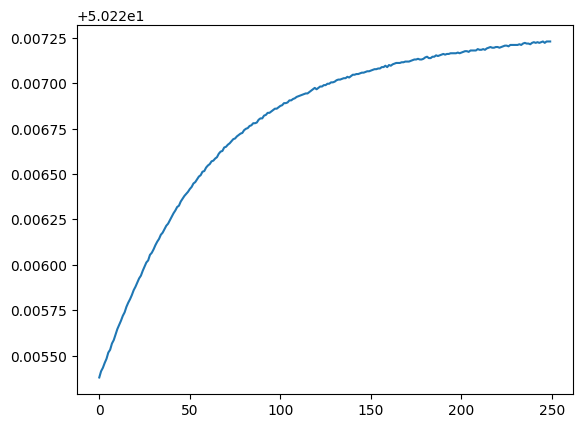

In [ ]:
plt.plot([k for k in range(250)], biomass_list)

In [ ]:
print(P)

tensor([[0.0186, 0.1844, 0.0070],
        [0.0078, 0.0743, 0.0179],
        [0.9736, 0.7413, 0.9751]], grad_fn=<SoftmaxBackward0>)


In [ ]:
lrs, losses = lr_finder(X_ini_one_layer_torch(N, nb_colonnes_default), T, N, nb_colonnes_default, L, H, D, u, CFL)

[autoreload of pytorch_optim failed: Traceback (most recent call last):
  File "C:\Users\octav\AppData\Roaming\Python\Python312\site-packages\IPython\extensions\autoreload.py", line 322, in check
    elif self.deduper_reloader.maybe_reload_module(m):
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\octav\AppData\Roaming\Python\Python312\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 545, in maybe_reload_module
    new_source_code = f.read()
                      ^^^^^^^^
  File "c:\Users\octav\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x8f in position 5359: character maps to <undefined>
]


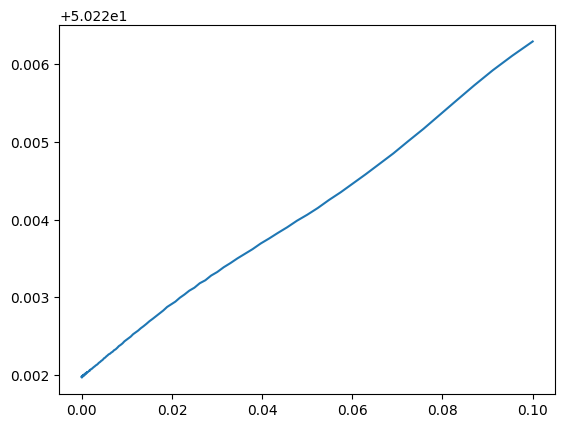

In [ ]:
plt.plot(lrs, -losses)

In [ ]:

T = 300
P, biomass_list = solve_fast(X_ini_one_layer_torch(N, nb_colonnes_default), T, N, nb_colonnes_default, L, H, D, u, CFL)


NameError: name 'solve_fast' is not defined

In [ ]:
T = 50
LBFGS(X_ini_one_layer_torch(N, nb_colonnes_default), T, N, nb_colonnes_default, L, H, D, u, CFL)

TypeError: LBFGS.step() missing 1 required positional argument: 'closure'